In [1]:
import sys, os
# ensure parent directory is on the path so `src` package can be imported
sys.path.insert(0, os.path.abspath('..'))

In [2]:
# configura per importare da src
import sys
sys.path.append('./src')

## Box creation

### Load dataset

In [3]:
import re

concepts_file = '../AwA2_Dataset_Labels/Animals_with_Attributes2/extended_concepts.txt'
def parse_concepts(filepath):
    """Legge il file dei concetti e restituisce una lista ordinata."""
    concepts = []
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            # Rimuove eventuali tag come 
            line = re.sub(r'\\', '', line).strip()
            if not line:
                continue
            parts = line.split()
            # Assumiamo che il primo elemento sia l'ID e il resto il nome del concetto
            if len(parts) >= 2:
                concepts.append(parts[1])
    return concepts
concepts = parse_concepts(concepts_file)

In [4]:
import re

classes_file = '../AwA2_Dataset_Labels/Animals_with_Attributes2/classes.txt'
def parse_classes(filepath):
    """Legge il file delle classi e restituisce una lista ordinata."""
    classes = []
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            # Rimuove eventuali tag come 
            line = re.sub(r'\\', '', line).strip()
            if not line:
                continue
            parts = line.split()
            # Assumiamo che il primo elemento sia l'ID e il resto il nome della classe
            if len(parts) >= 2:
                classes.append(parts[1])
    return classes

classes = parse_classes(classes_file)

In [5]:
import json

JSON_PATH='../AwA2_Dataset_Labels/Animals_with_Attributes2/supervisioni_gerarchia.json'
def load_data(json_path, concepts):
    with open(json_path, 'r') as f:
        data = json.load(f)
        
    concept2id = {c: idx for idx, c in enumerate(concepts)}
    id2concept = {idx: c for c, idx in concept2id.items()}
    
    # Prepariamo il dataset nel formato [(id_i, id_j, label), ...]
    dataset = []
    for item in data:
        dataset.append((concept2id[item[0]], concept2id[item[1]], float(item[2])))
        
    return dataset, concept2id, id2concept

In [6]:
dataset, concept2id, id2concept = load_data(JSON_PATH, concepts)

### Train

In [7]:
from src.CHM.model import BoxHierarchyModel
from src.CHM.train import train_box
import torch.nn as nn
from torch.optim import Adam

LR = 0.05

box_model = BoxHierarchyModel(num_concepts=len(concept2id), dim=32)
optimizer = Adam(box_model.parameters(), lr=LR)
criterion = nn.BCELoss() # Binary Cross Entropy

AllenNLP not available. Registrable won't work.


In [8]:
train_box(box_model, optimizer, criterion, dataset, concept2id, id2concept)

Trovati 50 concetti unici e 583 relazioni supervisionate.

Inizio Addestramento...
Epoca [1/100] | Loss: 1.4628
Epoca [10/100] | Loss: 0.1925
Epoca [20/100] | Loss: 0.0551
Epoca [30/100] | Loss: 0.0210
Epoca [40/100] | Loss: 0.0106
Epoca [50/100] | Loss: 0.0065
Epoca [60/100] | Loss: 0.0048
Epoca [70/100] | Loss: 0.0039
Epoca [80/100] | Loss: 0.0034
Epoca [90/100] | Loss: 0.0031
Epoca [100/100] | Loss: 0.0029

Addestramento completato!

Verifica di alcune predizioni post-addestramento:
Relazione: Animal | arm
 - P_teorica: 1.0 -> P_predetta: 1.0000
Relazione: lower_body_part | big
 - P_teorica: 0.0 -> P_predetta: 0.0052
Relazione: yellow | wings
 - P_teorica: 0.0 -> P_predetta: 0.0000


### Visualization

In [9]:
from src.CHM.visualization import visualize_concept_hierarchy, visualize_heatmap_compare, visualize_all_boxes_2d

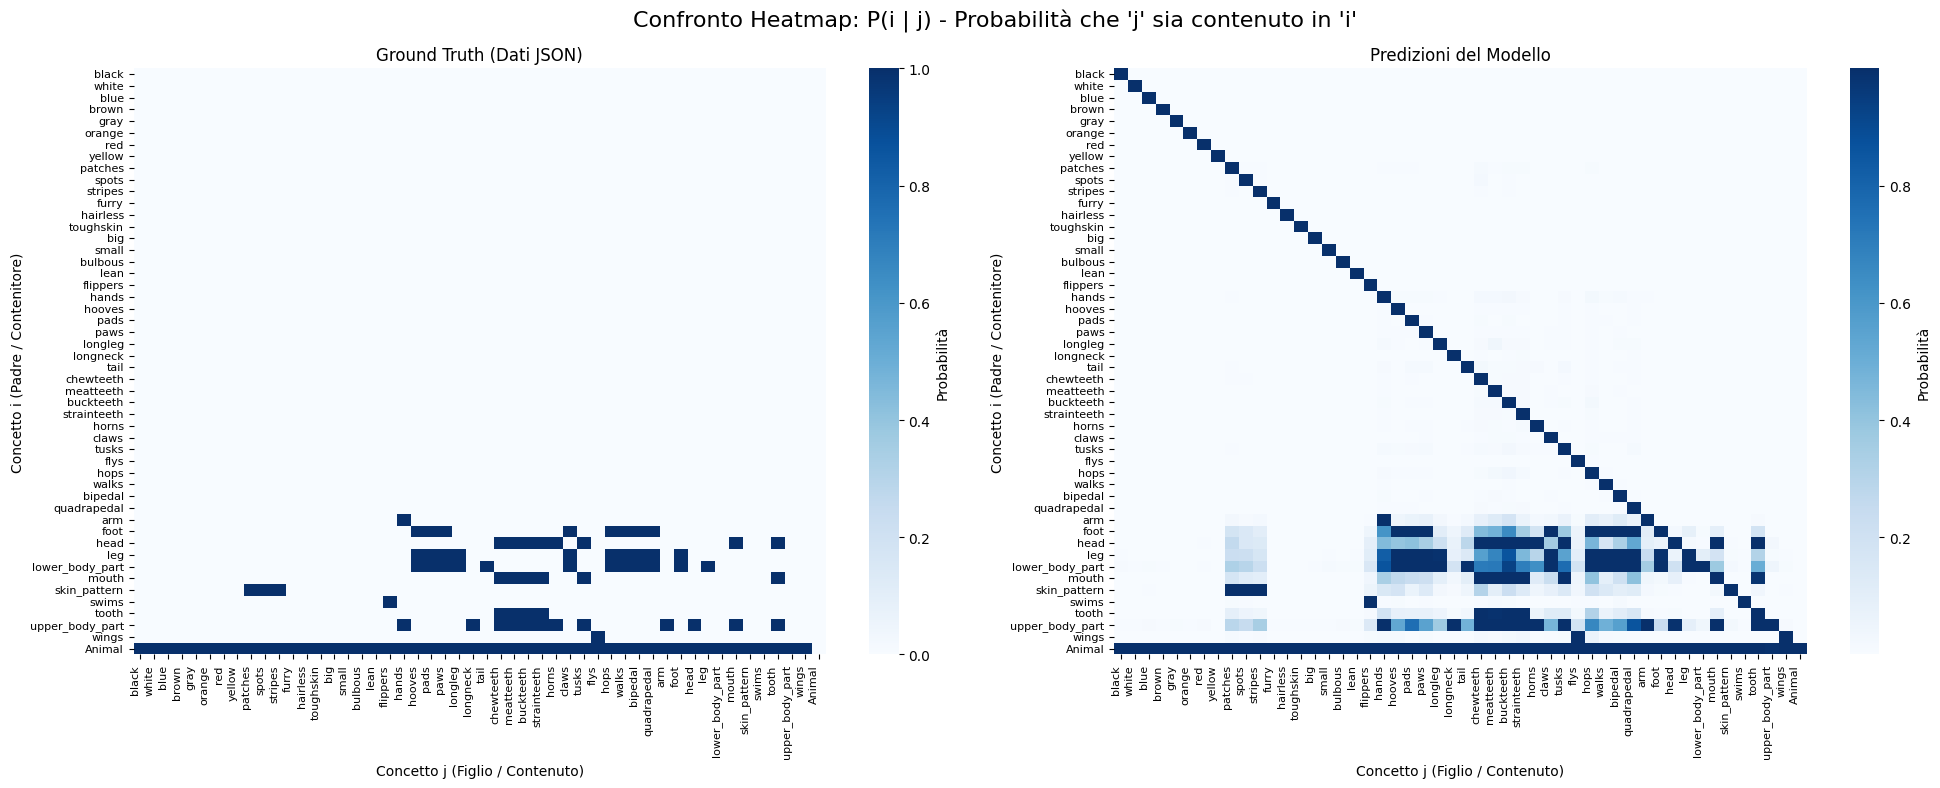

In [10]:
visualize_heatmap_compare(box_model, dataset, concept2id, id2concept)

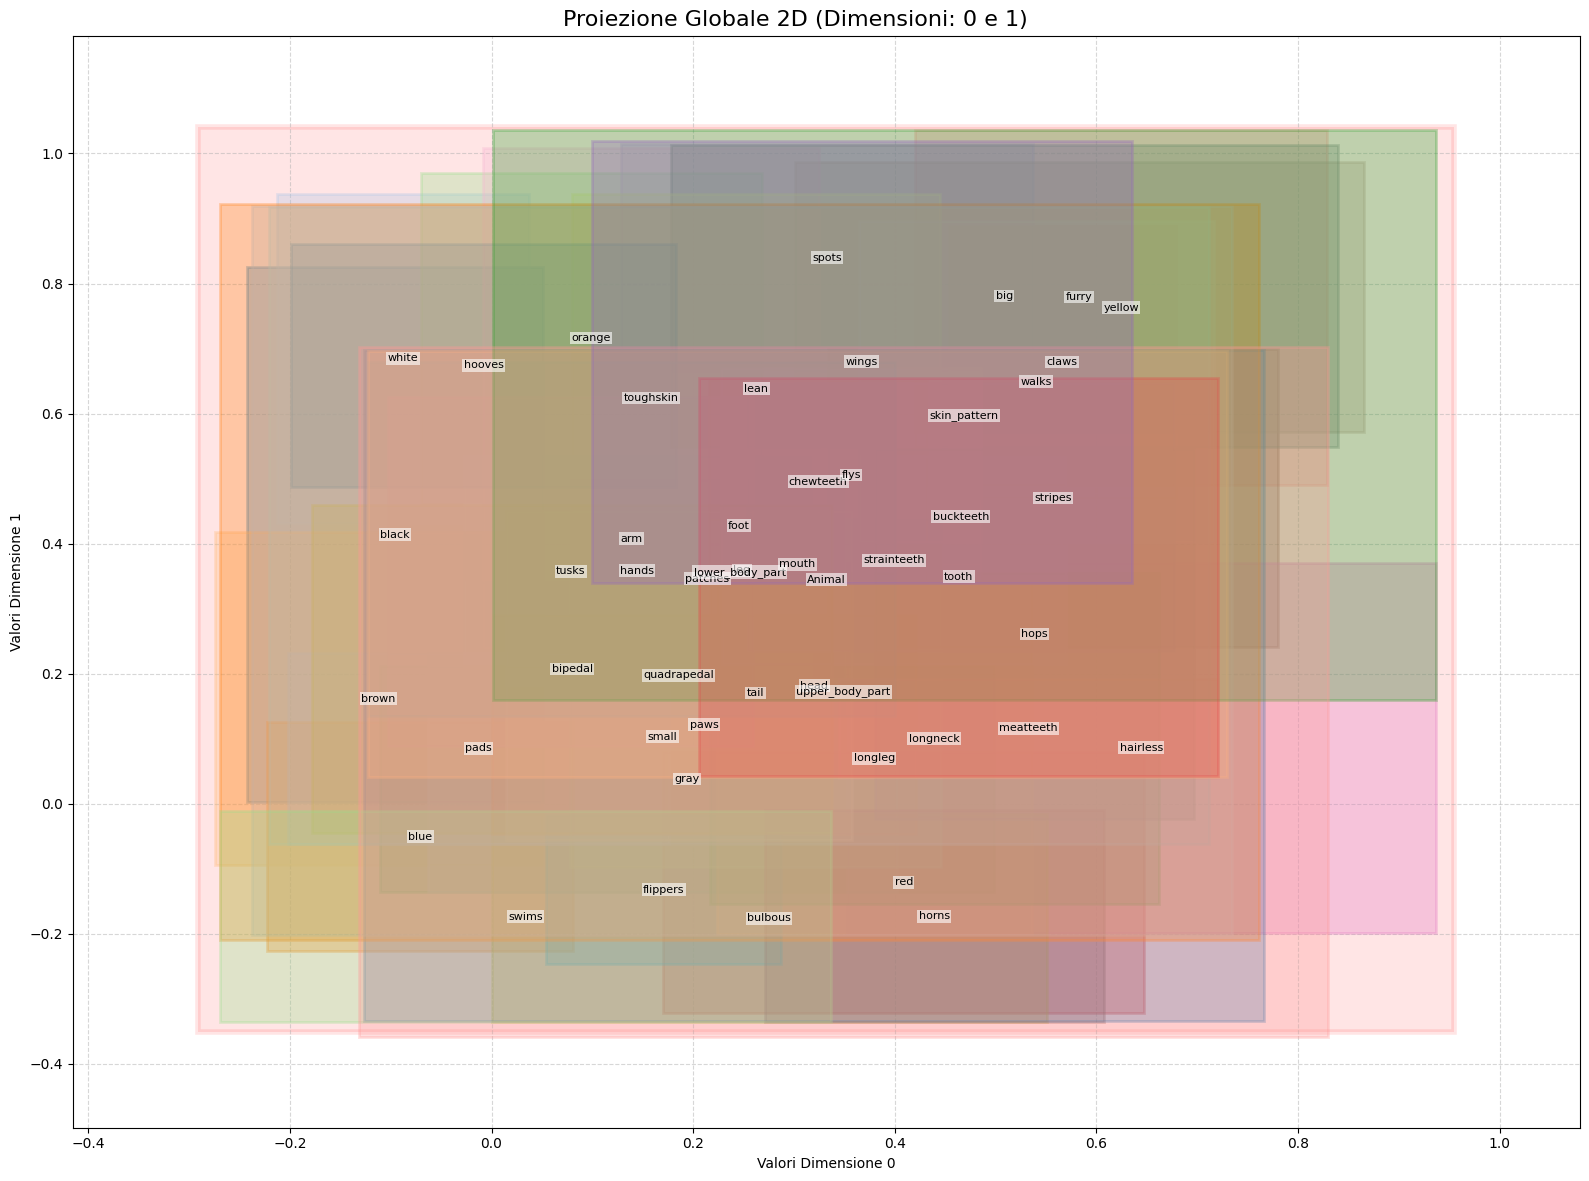

In [11]:
# cambiare dim_x e dim_y (da 0 a 31) per esplorare la "forma" da diverse angolazioni
visualize_all_boxes_2d(box_model, id2concept, dim_x=0, dim_y=1)

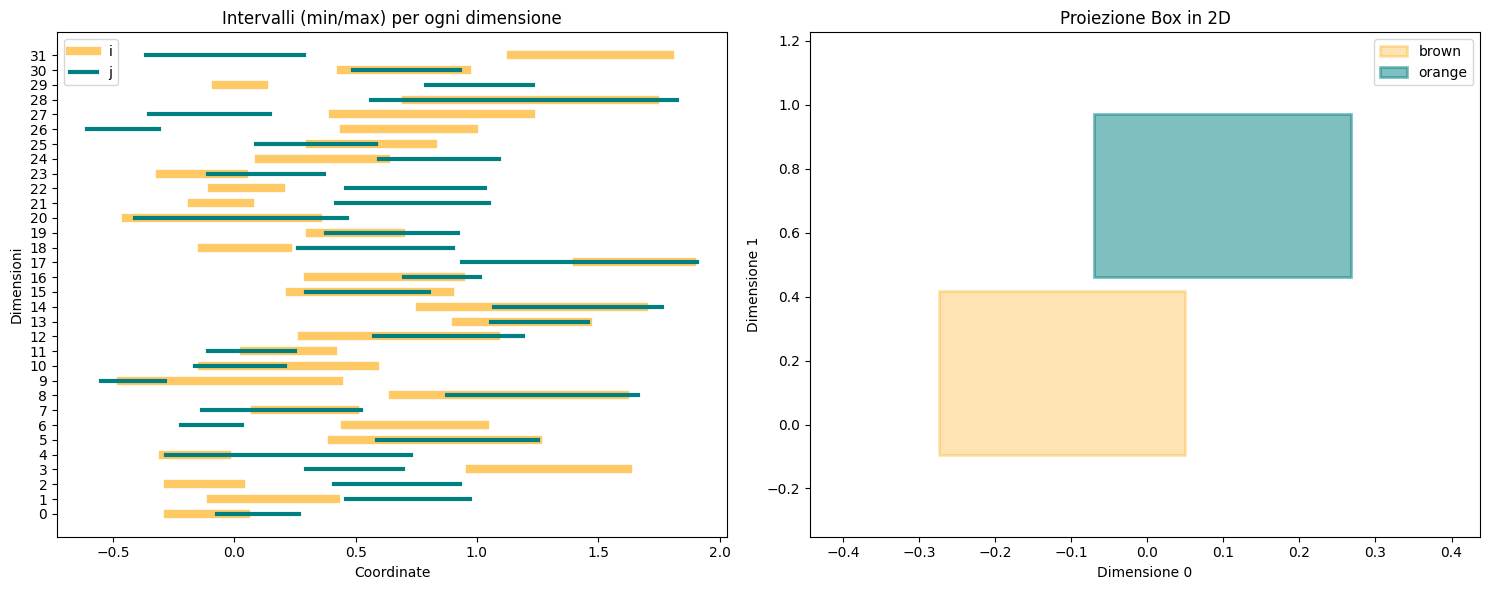

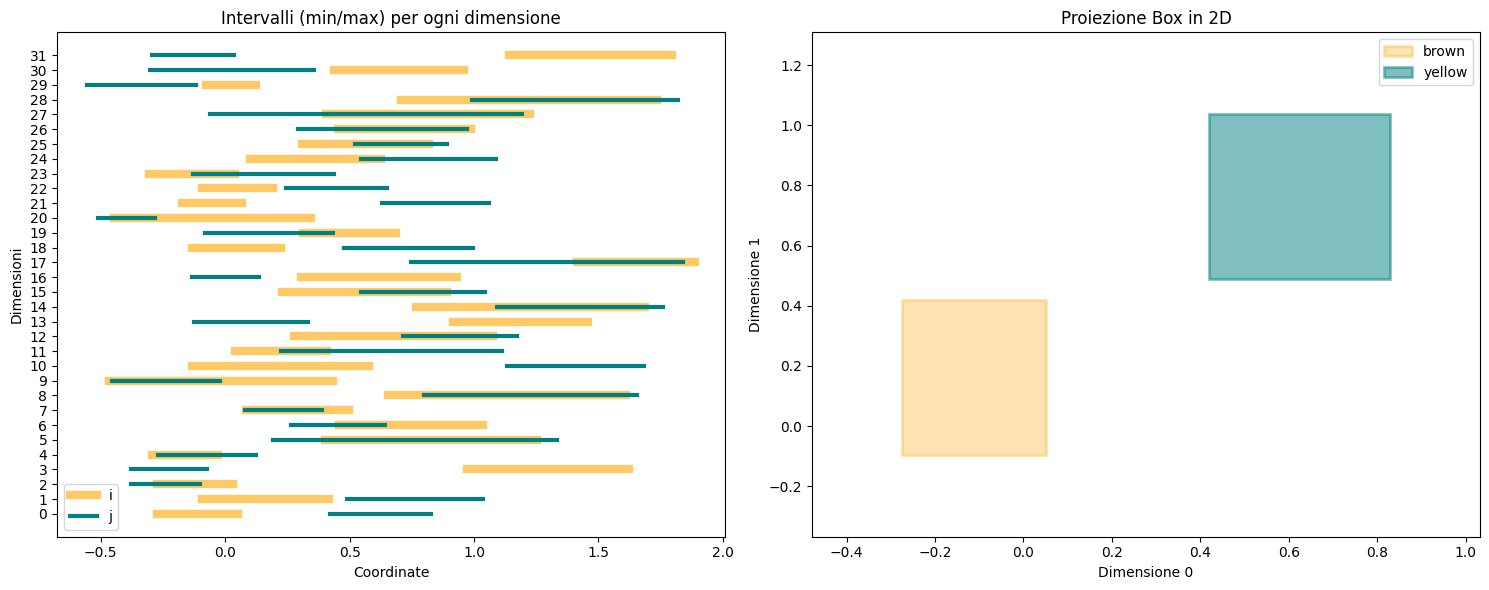

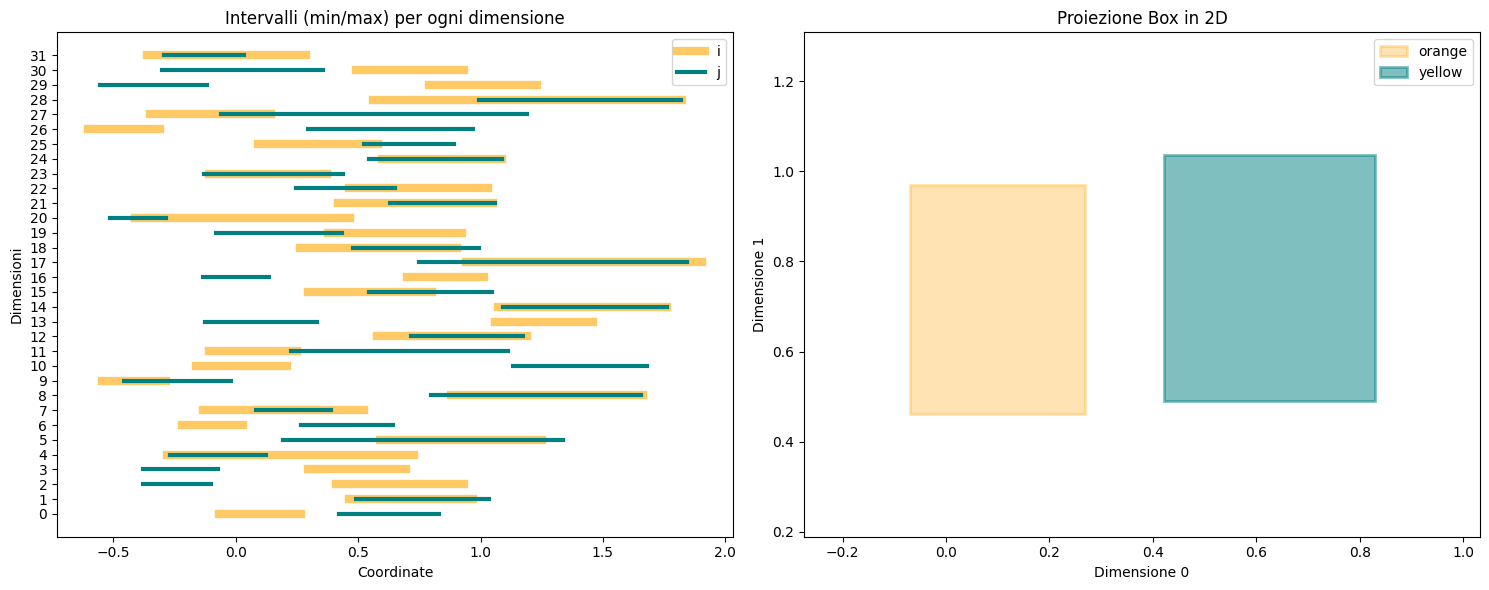

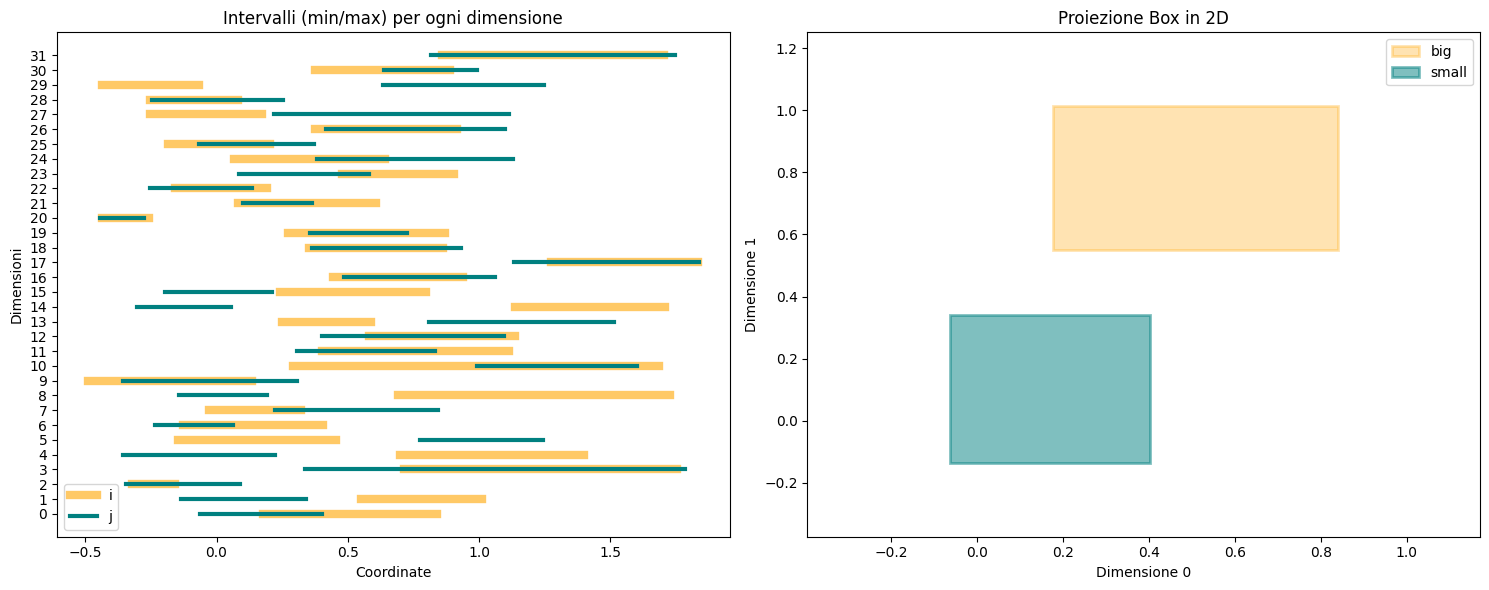

In [12]:
visualize_concept_hierarchy(box_model, id2concept, concept2id, "brown", "orange")
visualize_concept_hierarchy(box_model, id2concept, concept2id, "brown", "yellow")
visualize_concept_hierarchy(box_model, id2concept, concept2id, "orange", "yellow")
visualize_concept_hierarchy(box_model, id2concept, concept2id, "big", "small")

### Save boxes

In [13]:
from src.utils.box import get_box_dict

box_dict = get_box_dict(box_model, id2concept)

## CBM

### Load dataset

In [14]:
import torch
torch.save(box_model.state_dict(), "modello_gerarchia.pth")

In [15]:
box_model.load_state_dict(torch.load("modello_gerarchia.pth"))

<All keys matched successfully>

In [16]:
box_dict = get_box_dict(box_model, id2concept)

In [17]:
from src.utils.dataset import classical_split_awa2_features
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
from src.utils.box import prepara_tensore_box

features_path = '../AwA2_Dataset_Features/Animals_with_Attributes2/Features/ResNet101/AwA2-features.txt'
labels_path = '../AwA2_Dataset_Features/Animals_with_Attributes2/Features/ResNet101/AwA2-labels.txt'

(X_train, y_train), (X_val, y_val), (X_test, y_test) = classical_split_awa2_features(
    features_path, labels_path, test_size=0.2, val_size=0.1, random_seed=42
)
class_concept_matrix = torch.from_numpy(np.loadtxt('../Awa2_Dataset_Labels/Animals_with_Attributes2/extended_matrix.txt', dtype=int))

box_tensors = prepara_tensore_box(box_dict, concept2id)

BOX_DIM = 32
BATCH_SIZE = 32
EPOCHS = 20
NUM_CLASSES = len(set(y_train))
NUM_CONCEPTS = len(concept2id)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

train_dataset = TensorDataset(torch.tensor(X_train).float(), torch.tensor(y_train).long())
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)
val_dataset = TensorDataset(torch.tensor(X_val).float(), torch.tensor(y_val).long())
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, pin_memory=True)
test_dataset = TensorDataset(torch.tensor(X_test).float(), torch.tensor(y_test).long())
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, pin_memory=True)

Caricamento dei dati in corso... (potrebbe richiedere qualche secondo)
Dataset caricato correttamente: 37322 campioni con 2048 feature ciascuno.

--- Risultati dello Split Stratificato (50 Classi) ---
Training set:   26124 campioni
Validation set: 3733 campioni
Test set:       7465 campioni
Using device: cpu


In [18]:
from src.CHM.model import ConceptBottleneckClassifier
from src.CHM.train import train_cbm_classifier
import matplotlib.pyplot as plt
from src.CHM.test import test_cbm_classifier
from src.utils.plot import plot_test_results

### ORACLE

#### Train

In [19]:
info = "rel_matrix"
b_model = ConceptBottleneckClassifier(
    box_dim=box_tensors.size(-1), 
    num_classes=NUM_CLASSES, 
    num_concepts=NUM_CONCEPTS,
    info=info
)
optimizer = torch.optim.Adam(b_model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

b_history = train_cbm_classifier(
    b_model, 
    train_dataloader, 
    val_dataloader, 
    optimizer, 
    criterion, 
    class_concept_matrix, 
    box_tensors, 
    EPOCHS, 
    device,
    info=info
)

Inizio addestramento del classificatore (c -> y)...
Epoca   2/20 | TRAIN: Loss=2.869, Acc=24.2% | VAL: Loss=2.449, Acc=27.1%
Epoca   3/20 | TRAIN: Loss=2.225, Acc=44.7% | VAL: Loss=2.054, Acc=47.1%
Epoca   4/20 | TRAIN: Loss=1.918, Acc=57.7% | VAL: Loss=1.806, Acc=61.7%
Epoca   5/20 | TRAIN: Loss=1.692, Acc=66.4% | VAL: Loss=1.596, Acc=67.7%
Epoca   6/20 | TRAIN: Loss=1.506, Acc=70.7% | VAL: Loss=1.423, Acc=76.3%
Epoca   7/20 | TRAIN: Loss=1.351, Acc=74.6% | VAL: Loss=1.284, Acc=72.2%
Epoca   8/20 | TRAIN: Loss=1.214, Acc=77.6% | VAL: Loss=1.159, Acc=79.3%
Epoca   9/20 | TRAIN: Loss=1.098, Acc=80.0% | VAL: Loss=1.029, Acc=83.4%
Epoca  10/20 | TRAIN: Loss=0.995, Acc=83.0% | VAL: Loss=0.948, Acc=80.0%
Epoca  11/20 | TRAIN: Loss=0.906, Acc=85.1% | VAL: Loss=0.859, Acc=87.5%
Epoca  12/20 | TRAIN: Loss=0.829, Acc=86.9% | VAL: Loss=0.795, Acc=81.4%
Epoca  13/20 | TRAIN: Loss=0.761, Acc=87.5% | VAL: Loss=0.726, Acc=87.3%
Epoca  14/20 | TRAIN: Loss=0.700, Acc=89.3% | VAL: Loss=0.674, Acc=92.4%

#### Test

In [20]:
accuracy, preds, labels = test_cbm_classifier(
     model=b_model,
     test_dataloader=test_dataloader,
     class_concept_matrix=class_concept_matrix,
     boxes_tensor=box_tensors,
     oracle=True,
     device="cuda" if torch.cuda.is_available() else "cpu",
     info=info
)

Inizio valutazione sul Test Set...

Accuratezza Totale: 85.45%


### ABLATION SABOTAGE

In [21]:
# 1. Definiamo i "Nodi Padre" (Macro Concept) da SALVARE
macro_concepts_to_keep = [
    'Animal', 
    'upper_body_part', 
    'lower_body_part', 
    'head', 
    'leg', 
    'foot', 
    'mouth', 
    'tooth', 
    'skin_pattern'
]

# 2. Generiamo il sabotaggio per TUTTE le classi
extreme_modifications = []
for cls_name in classes:
    for concept in concepts: # Assicurati di avere a scope la lista completa dei nomi dei concetti
        # Se il concetto NON è nella lista dei macro-concetti, lo radiamo al suolo (0.0)
        if concept not in macro_concepts_to_keep:
            extreme_modifications.append((cls_name, concept, 0.0))

# 3. (Opzionale) Iniezioni Letali (Falsi Positivi)
# Visto che stiamo già azzerando tutte le foglie, l'accuracy crollerà comunque.
# Tuttavia, aggiungere un'allucinazione (es. dare le pinne alla tigre) DOPO
# averle tolto tutti i suoi tratti distintivi, manderà i logit completamente in negativo.
iniezioni_letali = [
    ('killer+whale', 'hooves', 1.0), # Un'orca con gli zoccoli
    ('tiger', 'flippers', 1.0),      # Una tigre con le pinne
    ('horse', 'flys', 1.0),          # Un cavallo che vola
    ('bat', 'tusks', 1.0),           # Un pipistrello con le zanne da elefante
    ('moose', 'spots', 1.0)          # Un alce a pois
]

extreme_modifications.extend(iniezioni_letali)

In [22]:
# Un sabotaggio chirurgico su 5 classi per testare l'Antivirus Logico
virus_modifications = [
    # 1. TIGRE: La trasformiamo in un erbivoro
    ('tiger', 'hooves', 1.0),      # Iniezione zoccoli
    ('tiger', 'horns', 1.0),       # Iniezione corna
    ('tiger', 'chewteeth', 1.0),   # Iniezione denti piatti
    ('tiger', 'stripes', 0.0),     # Spegniamo il suo tratto forte
    
    # 2. CAVALLO: Lo trasformiamo in un predatore
    ('horse', 'meatteeth', 1.0),
    ('horse', 'claws', 1.0),
    ('horse', 'hooves', 0.0),
    
    # 3. DELFINO: Lo facciamo diventare terrestre
    ('dolphin', 'longleg', 1.0),
    ('dolphin', 'furry', 1.0),
    ('dolphin', 'walks', 1.0),
    ('dolphin', 'flippers', 0.0),
    
    # 4. PIPISTRELLO: Lo facciamo diventare un animale marino
    ('bat', 'swims', 1.0),
    ('bat', 'flippers', 1.0),
    ('bat', 'wings', 0.0),
    ('bat', 'flys', 0.0),
    
    # 5. ORSO GRIZZLY: Lo facciamo diventare una scimmia
    ('grizzly+bear', 'hands', 1.0),
    ('grizzly+bear', 'tail', 1.0), # (Gli orsi non hanno coda lunga in questo dataset)
    ('grizzly+bear', 'big', 0.0)
]

In [23]:
from src.utils.ablation import sabotage_concept_matrix

sabotaged_matrix = sabotage_concept_matrix(
    class_concept_matrix,
    classes,
    concepts,
    extreme_modifications,
)

Sabotaggio: antelope -> black | Vecchio: 0.0 -> Nuovo: 0.0
Sabotaggio: antelope -> white | Vecchio: 0.0 -> Nuovo: 0.0
Sabotaggio: antelope -> blue | Vecchio: 0.0 -> Nuovo: 0.0
Sabotaggio: antelope -> brown | Vecchio: 0.0 -> Nuovo: 0.0
Sabotaggio: antelope -> gray | Vecchio: 0.0 -> Nuovo: 0.0
Sabotaggio: antelope -> orange | Vecchio: 0.0 -> Nuovo: 0.0
Sabotaggio: antelope -> red | Vecchio: 0.0 -> Nuovo: 0.0
Sabotaggio: antelope -> yellow | Vecchio: 0.0 -> Nuovo: 0.0
Sabotaggio: antelope -> patches | Vecchio: 0.0 -> Nuovo: 0.0
Sabotaggio: antelope -> spots | Vecchio: 0.0 -> Nuovo: 0.0
Sabotaggio: antelope -> stripes | Vecchio: 0.0 -> Nuovo: 0.0
Sabotaggio: antelope -> furry | Vecchio: 1.0 -> Nuovo: 0.0
Sabotaggio: antelope -> hairless | Vecchio: 0.0 -> Nuovo: 0.0
Sabotaggio: antelope -> toughskin | Vecchio: 1.0 -> Nuovo: 0.0
Sabotaggio: antelope -> big | Vecchio: 1.0 -> Nuovo: 0.0
Sabotaggio: antelope -> small | Vecchio: 0.0 -> Nuovo: 0.0
Sabotaggio: antelope -> bulbous | Vecchio: 0.0 ->

In [24]:
from src.utils.ablation import sabotage_concept_matrix
sabotaged_matrix = sabotage_concept_matrix(
    class_concept_matrix, 
    classes, 
    concepts, 
    virus_modifications
)

Sabotaggio: tiger -> hooves | Vecchio: 0.0 -> Nuovo: 1.0
Sabotaggio: tiger -> horns | Vecchio: 0.0 -> Nuovo: 1.0
Sabotaggio: tiger -> chewteeth | Vecchio: 1.0 -> Nuovo: 1.0
Sabotaggio: tiger -> stripes | Vecchio: 1.0 -> Nuovo: 0.0
Sabotaggio: horse -> meatteeth | Vecchio: 0.0 -> Nuovo: 1.0
Sabotaggio: horse -> claws | Vecchio: 0.0 -> Nuovo: 1.0
Sabotaggio: horse -> hooves | Vecchio: 1.0 -> Nuovo: 0.0
Sabotaggio: dolphin -> longleg | Vecchio: 0.0 -> Nuovo: 1.0
Sabotaggio: dolphin -> furry | Vecchio: 0.0 -> Nuovo: 1.0
Sabotaggio: dolphin -> walks | Vecchio: 0.0 -> Nuovo: 1.0
Sabotaggio: dolphin -> flippers | Vecchio: 1.0 -> Nuovo: 0.0
Sabotaggio: bat -> swims | Vecchio: 0.0 -> Nuovo: 1.0
Sabotaggio: bat -> flippers | Vecchio: 0.0 -> Nuovo: 1.0
Sabotaggio: bat -> wings | Vecchio: 1.0 -> Nuovo: 0.0
Sabotaggio: bat -> flys | Vecchio: 1.0 -> Nuovo: 0.0
Sabotaggio: grizzly+bear -> hands | Vecchio: 0.0 -> Nuovo: 1.0
Sabotaggio: grizzly+bear -> tail | Vecchio: 0.0 -> Nuovo: 1.0
Sabotaggio: griz

In [25]:
accuracy, preds, labels = test_cbm_classifier(
     model=b_model,
     test_dataloader=test_dataloader,
     class_concept_matrix=sabotaged_matrix,
     boxes_tensor=box_tensors,
     oracle=True,
     device="cuda" if torch.cuda.is_available() else "cpu",
     info=info
)

Inizio valutazione sul Test Set...

Accuratezza Totale: 86.97%


### RELATION MATRIX FEEDBACK

In [26]:
accuracy, preds, labels = test_cbm_classifier(
     model=b_model,
     test_dataloader=test_dataloader,
     class_concept_matrix=sabotaged_matrix,
     boxes_tensor=box_tensors,
     oracle=True,
     device="cuda" if torch.cuda.is_available() else "cpu",
     smoothing_logic=True,
     alpha=0.1,
     info=info
)

Inizio valutazione sul Test Set...

Accuratezza Totale: 0.78%
